<a href="https://colab.research.google.com/github/eyluelo/oil_prices_time_analysis/blob/main/oilPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

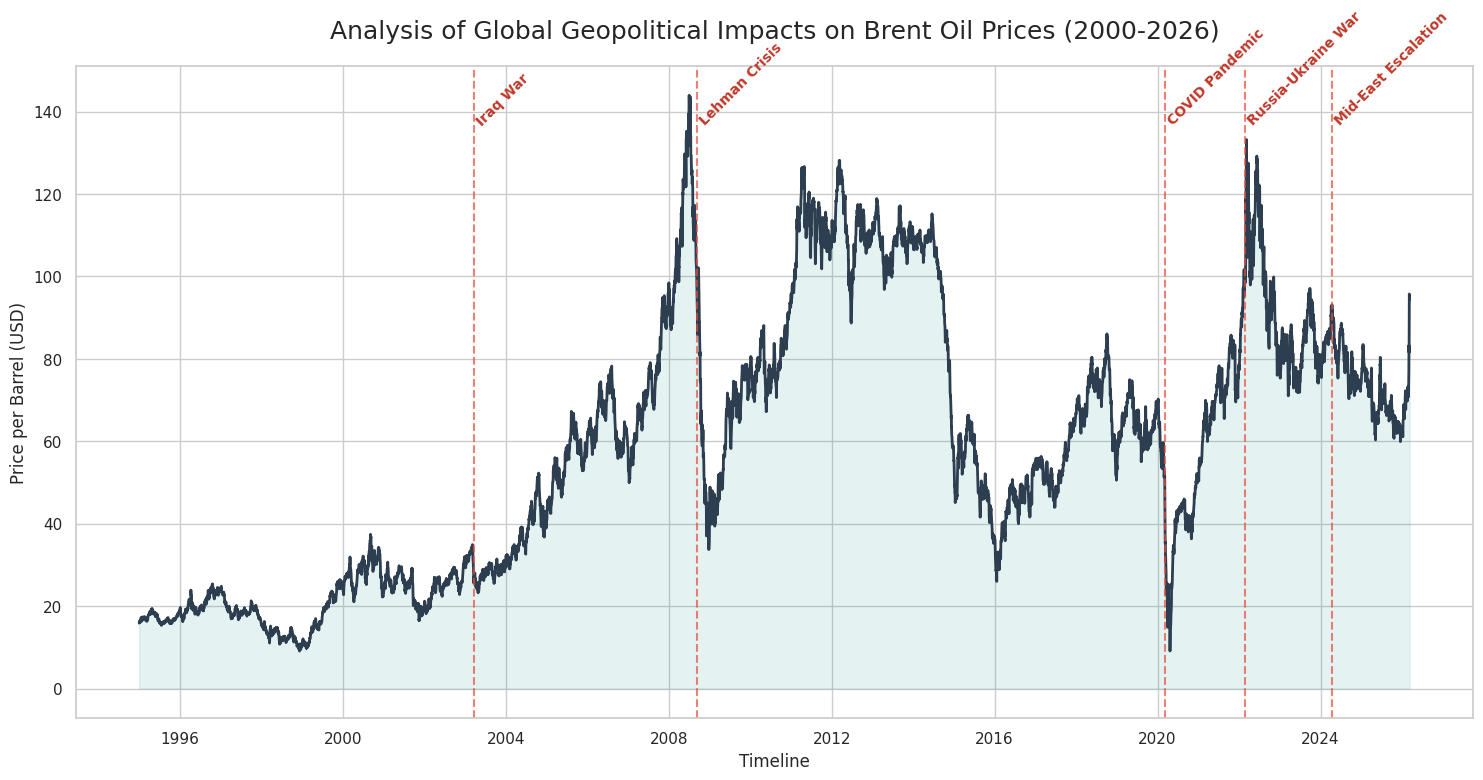

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from a reliable open-source repository
# This dataset contains daily Brent Crude Oil prices from 1987 to present
url = "https://raw.githubusercontent.com/datasets/oil-prices/master/data/brent-daily.csv"
df = pd.read_csv(url)

# 2. Pre-processing: Convert 'Date' column to datetime objects for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])

# Filter the data to focus on the 21st century (from year 2000 onwards)
# This makes the visualization cleaner and more relevant for modern analysis
df = df[df['Date'] >= '1995-01-01']# Visualization Setup
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid") # Using a clean, professional grid style

# Create the main line plot for oil prices
sns.lineplot(data=df, x='Date', y='Price', color='#2c3e50', linewidth=2)

# Adding Context
events = {
    '2003-03-20': 'Iraq War',
    '2008-09-15': 'Lehman Crisis',
    '2020-03-11': 'COVID Pandemic',
    '2022-02-24': 'Russia-Ukraine War',
    '2024-04-13': 'Mid-East Escalation'
}

# Iterate through events to draw vertical markers
for date, label in events.items():
    event_date = pd.to_datetime(date)
    # Draw a vertical dashed line for each event
    plt.axvline(event_date, color='#e74c3c', linestyle='--', alpha=0.7)

    # Add text labels on top of the lines
    plt.text(event_date, df['Price'].max() * 0.95, label,
             rotation=45, color='#c0392b', fontweight='bold', fontsize=10)

    # Final Formatting: Adding professional titles and labels
plt.title('Analysis of Global Geopolitical Impacts on Brent Oil Prices (2000-2026)', fontsize=18, pad=20)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Price per Barrel (USD)', fontsize=12)

# Adding a shaded area for better visual depth
plt.fill_between(df['Date'], df['Price'], color='teal', alpha=0.1)

plt.tight_layout()
plt.show()